# Importing libraries

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.utils import resample

# K-Mode clusting (Parameter tuning)

In [24]:
fen_df_mode = fen_df
col_to_drop = [col for col in fen_df_mode.columns if 'Condition' in col]

fen_df_mode = fen_df_mode.drop(columns=col_to_drop)
fen_df_mode = fen_df_mode.drop(columns=['Death Recode', 'Month of Death', 'Manner of Death', 'Age'], axis=1)

fen_df_mode.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning
1,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
2,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
3,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
4,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning


Cost for init method: Huang: 141086.0
Cost for init method: Random: 145771.0
Cost for init method: Cao: 152739.0


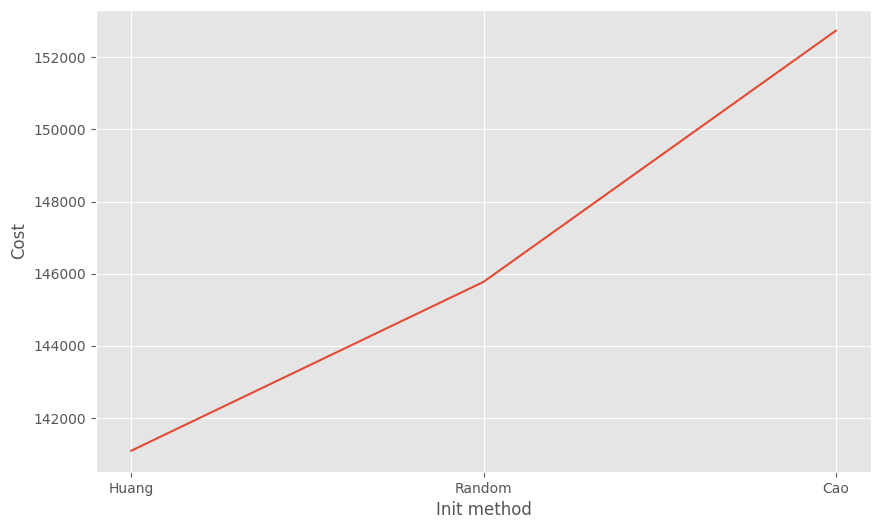

In [25]:
def find_init(data):
    init_tuning = ['Huang', 'Random', 'Cao']
    cost = []
    
    #Looping through the number of max features and finding the best
    for init in init_tuning:
        kmode = KModes(init=init, random_state=34)
        kmode.fit_predict(data)
        cost.append(kmode.cost_)
        print(f'Cost for init method: {init}: {kmode.cost_}')
    
    plt.figure(figsize=(10,6))
    plt.plot(init_tuning,cost)
    plt.xlabel('Init method')
    plt.ylabel('Cost')
    plt.grid(True)
    plt.show()

find_init(fen_df_mode)

Cost for ninit method: 4: 148707.0
Cost for ninit method: 8: 147845.0
Cost for ninit method: 12: 141086.0
Cost for ninit method: 16: 141086.0
Cost for ninit method: 20: 141086.0


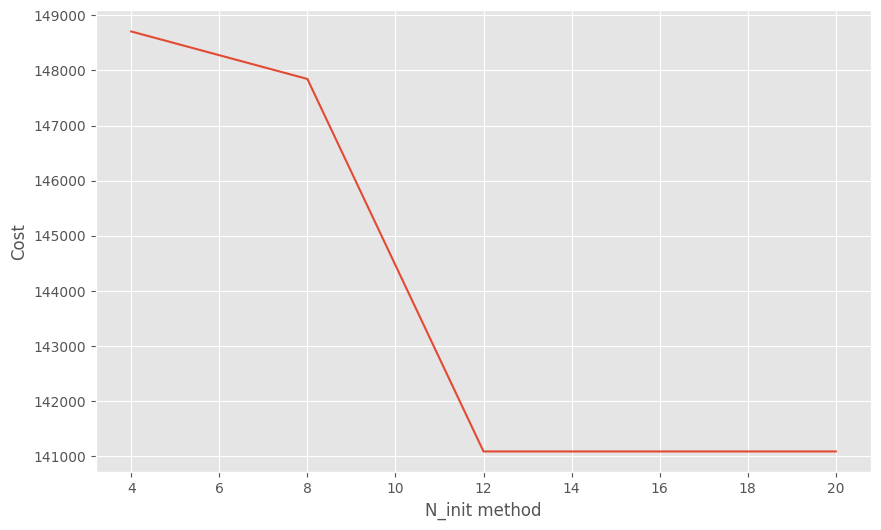

In [26]:
def find_ninit(data):
    ninit_tuning = [4, 8, 12, 16, 20]
    cost = []
    
    #Looping through the number of max features and finding the best
    for ninit in ninit_tuning:
        kmode = KModes(init='Huang', n_init=ninit, random_state=34)
        kmode.fit_predict(data)
        cost.append(kmode.cost_)
        print(f'Cost for ninit method: {ninit}: {kmode.cost_}')
    
    plt.figure(figsize=(10,6))
    plt.plot(ninit_tuning,cost)
    plt.xlabel('N_init method')
    plt.ylabel('Cost')
    plt.grid(True)
    plt.show()

find_ninit(fen_df_mode)

Cost for Max iterations: 100: 141086.0
Cost for Max iterations: 200: 141086.0
Cost for Max iterations: 300: 141086.0


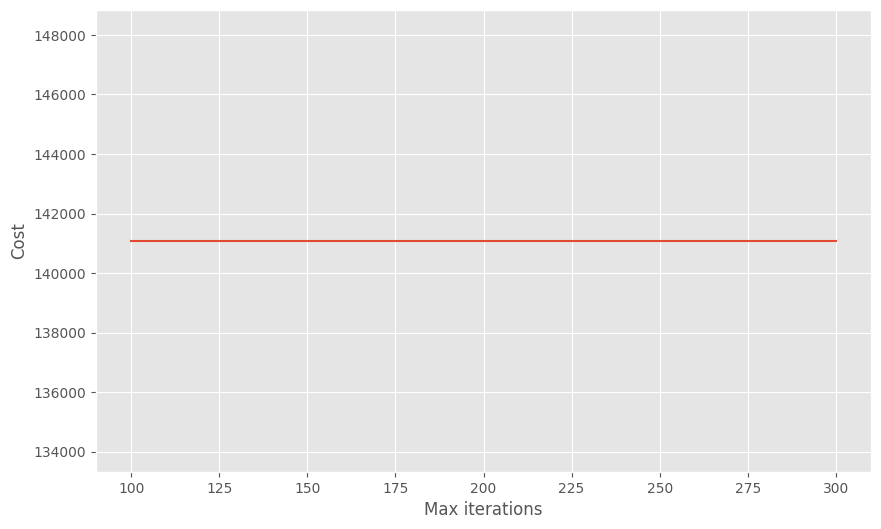

In [27]:
def find_max(data):
    max_tuning= [100, 200, 300]
    cost = []
    
    #Looping through the number of max features and finding the best
    for max in max_tuning:
        kmode = KModes(init='Huang', n_init=12, max_iter=max, random_state=34)
        kmode.fit_predict(data)
        cost.append(kmode.cost_)
        print(f'Cost for Max iterations: {max}: {kmode.cost_}')
    
    plt.figure(figsize=(10,6))
    plt.plot(max_tuning,cost)
    plt.xlabel('Max iterations')
    plt.ylabel('Cost')
    plt.grid(True)
    plt.show()

find_max(fen_df_mode)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 6, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 7, iteration: 1/100, moves: 0, cost: 214724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 8, ite

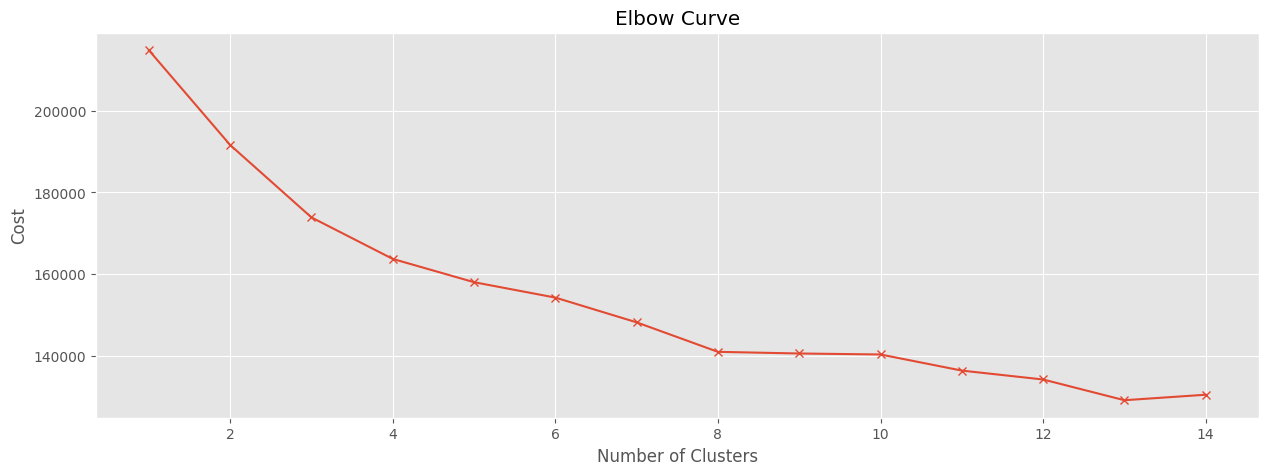

Elbow is at k = 4.000000 clusters


In [57]:
#Elbow method to find the number of clusters or k we are going to implement. Use KneeLocator to get the K value. Detects elbows if curve is convex. We use the tuned parameters from above.
def find_num_clusters(data, k):
    iters = range(1,k)
    
    cost = [] 
    for i in list(iters):
        kmode = KModes(n_clusters=i, init='Huang', n_init=12, max_iter=100, random_state=34, verbose=1) #init='Huang', n_init = 5, verbose = 1,
        kmode.fit_predict(data)
        cost.append(kmode.cost_)
        print('Fit {} clusters'.format(i))

    plt.plot(iters, cost, 'x-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Cost')
    plt.title('Elbow Curve')
    plt.show()

    #Get the K value. Detects elbows if curve is convex.
    knee = KneeLocator(x=iters, y=cost, S=0.1, curve='convex', direction='decreasing')
    K_knee = knee.elbow
    print('Elbow is at k =', f'{K_knee:0f} clusters')
    
find_num_clusters(fen_df_mode, 15)

# K mode clustering w/o dep feature: 

In [25]:
fen_df_mode

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning
1,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
2,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
3,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
4,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning
...,...,...,...,...,...,...,...
72231,8th grade or less,M,41 to 50,Marital Status unknown,White,Construction & Extraction Occupations,Accidental Drug Poisoning
72232,High school graduate or GED completed,F,51 to 65,Divorced,White,"Other, Housewife",Accidental Drug Poisoning
72233,High school graduate or GED completed,M,41 to 50,Divorced,Black,Transportation & Material Moving Occupations,Accidental Drug Poisoning
72234,High school graduate or GED completed,M,51 to 65,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [26]:
cost=[] #For testing 
k=4
kmode= KModes(n_clusters=k, init='Huang', n_init=12, max_iter=100, random_state=34)
clusters=kmode.fit_predict(fen_df_mode[['Education','Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation']])
cost.append(kmode.cost_)
print(cost)

clusters_dict = []

for c in clusters:
    clusters_dict.append(c)

fen_df_mode['Clusters'] = clusters_dict

[161943.0]


In [27]:
print(kmode.cluster_centroids_)

[['High school graduate or GED completed' 'M' '31 to 40'
  'Never married, single' 'White'
  'Food Preparation & Serving Related Occupations']
 ['9 - 12th grade, no diploma' 'M' '41 to 50' 'Married' 'White'
  'Other, Misc (exc Housewife)']
 ['High school graduate or GED completed' 'M' '51 to 65' 'Divorced'
  'White' 'Construction & Extraction Occupations']
 ['High school graduate or GED completed' 'M' '19 to 30'
  'Never married, single' 'White' 'Other, Misc (exc Housewife)']]


In [28]:
fen_df_mode['Clusters'].value_counts()

0    32040
3    15029
2    12899
1    12255
Name: Clusters, dtype: int64

In [ ]:
fen_df_mode['Clusters'] = fen_df_mode['Clusters'] + 1

In [30]:
fen_df_mode['Clusters'].value_counts()

1    32040
4    15029
3    12899
2    12255
Name: Clusters, dtype: int64

In [31]:
fen_df_mode.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death,Clusters
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning,3
1,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning,2
2,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning,1
3,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning,4
4,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning,3


In [ ]:
frequency_edu = fen_df_mode.pivot_table(index='Clusters', columns='Education', aggfunc='size')

frequency_edu

Education,8th grade or less,"9 - 12th grade, no diploma",Associate degree,Bachelors degree,Doctorate or professional degree,High school graduate or GED completed,Masters degree,"Some college credit, but no degree",Unknown
Clusters,,,,,,,,,
1,1092,4110,1759,1690,76,17712,283,4835,483
2,507,5034,789,696,66,1981,142,1768,1272
3,376,1210,551,466,31,8601,99,1367,198
4,372,2262,518,496,20,8721,40,2255,345


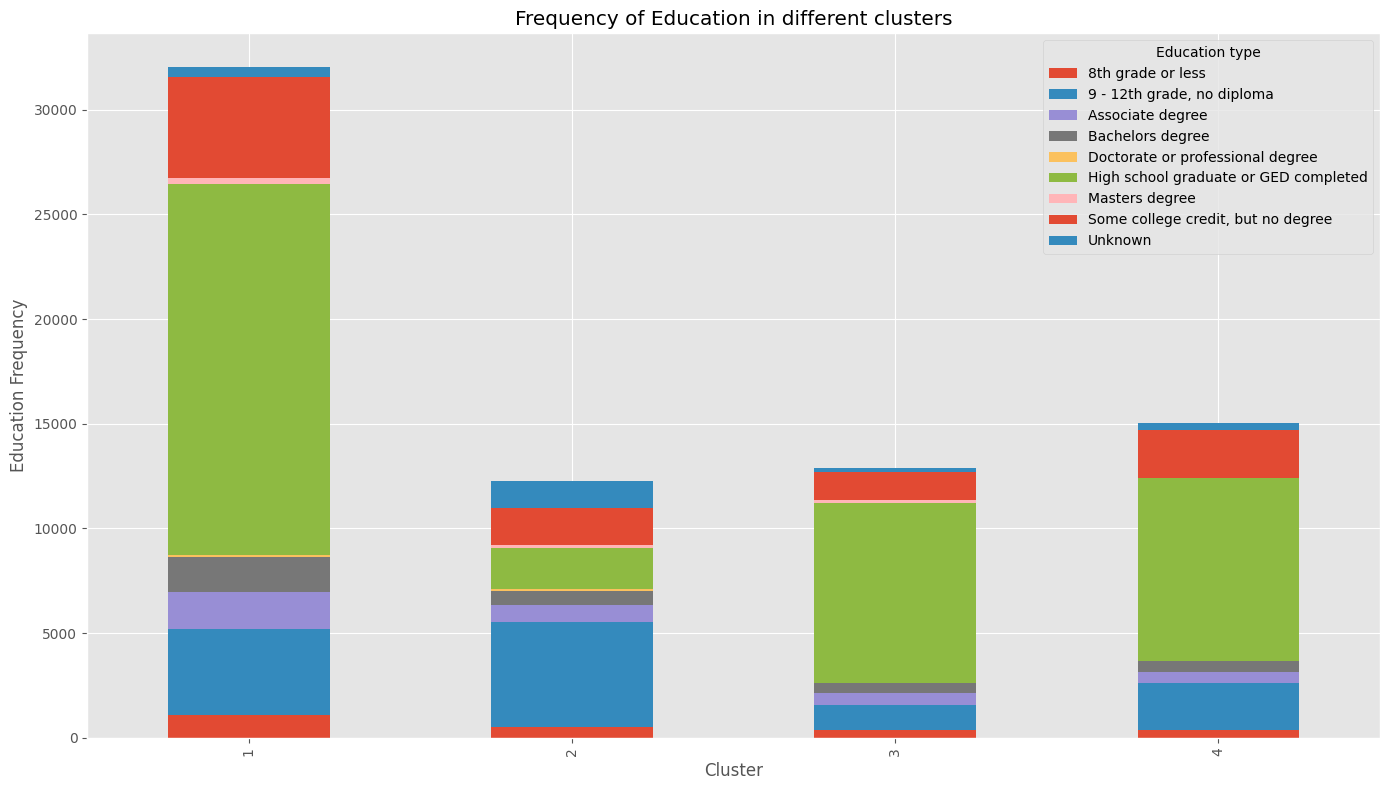

In [ ]:
frequency_edu.plot(kind='bar', figsize=(14, 8), stacked=True) #color=['#DAA520', '#4682B4', '#20B2AA', '#C71585', '#FF4500']) #width=0.8 
plt.title('Frequency of Education in different clusters')
plt.ylabel('Education Frequency')
plt.xlabel('Cluster')
plt.legend(title='Education type') 
plt.tight_layout() 
#plt.savefig('Education_without_death.png')
plt.show()

In [ ]:
frequency_death = fen_df_mode.pivot_table(index='Clusters', columns='Death', aggfunc='size')

frequency_death

Death,Accidental Drug Poisoning,Other
Clusters,,
1,30070,1970
2,11473,782
3,12064,835
4,14241,788


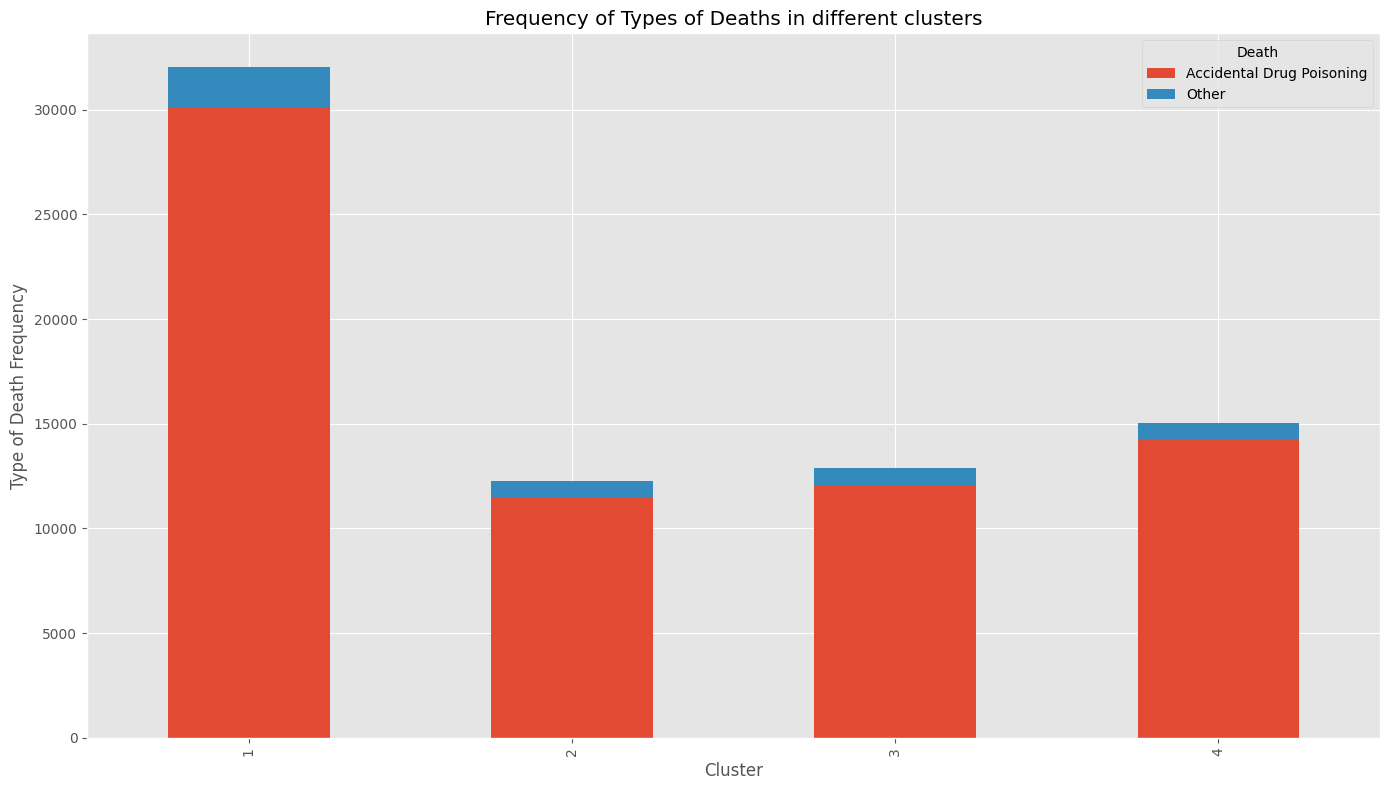

In [ ]:
frequency_death.plot(kind='bar', figsize=(14, 8), stacked=True)
plt.title('Frequency of Types of Deaths in different clusters')
plt.ylabel('Type of Death Frequency')
plt.xlabel('Cluster')
plt.legend(title='Death') 
plt.tight_layout() 
#plt.savefig('death_without_death.png')
plt.show()

In [ ]:
heat_edu = fen_df_mode.pivot_table(index='Education', columns='Clusters', aggfunc='size')
heat_edu

Clusters,1,2,3,4
Education,,,,
8th grade or less,1092,507,376,372
"9 - 12th grade, no diploma",4110,5034,1210,2262
Associate degree,1759,789,551,518
Bachelors degree,1690,696,466,496
Doctorate or professional degree,76,66,31,20
High school graduate or GED completed,17712,1981,8601,8721
Masters degree,283,142,99,40
"Some college credit, but no degree",4835,1768,1367,2255
Unknown,483,1272,198,345


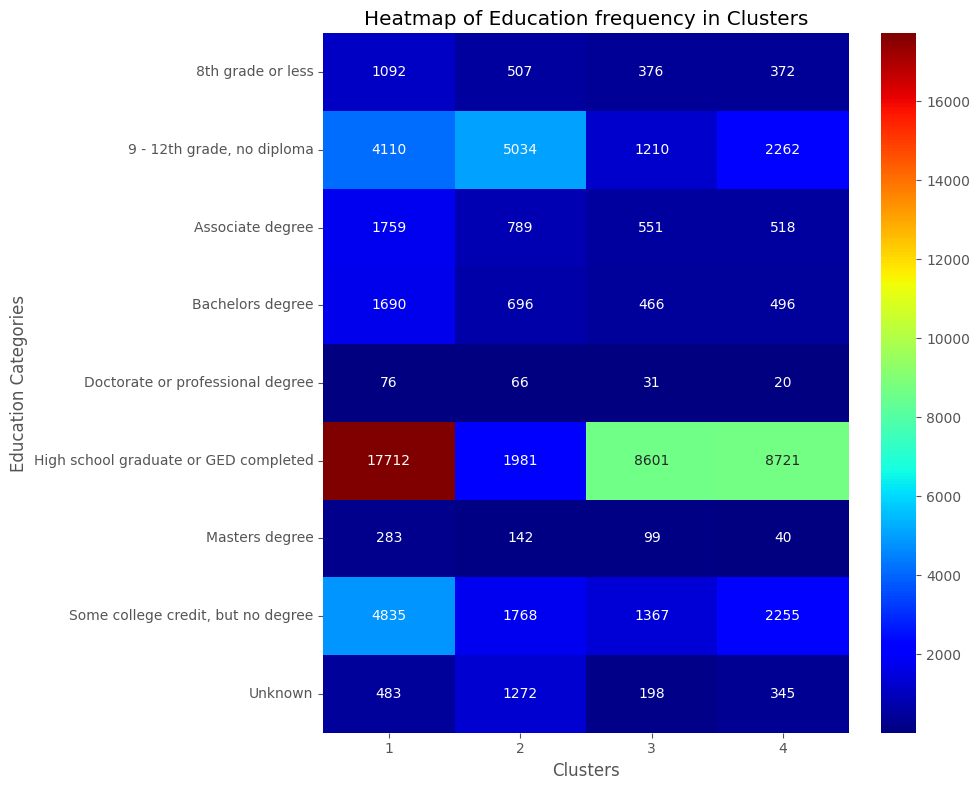

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(heat_edu, annot=True, fmt="d", cmap="jet") 
plt.title('Heatmap of Education frequency in Clusters')
plt.ylabel('Education Categories')
plt.xlabel('Clusters')
plt.tight_layout()
plt.savefig('edu_without_death.png')
plt.show()

# K mode clustering with rebalanced features 

In [196]:
fen_df_mode

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning
1,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
2,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
3,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
4,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning
...,...,...,...,...,...,...,...
72231,8th grade or less,M,41 to 50,Marital Status unknown,White,Construction & Extraction Occupations,Accidental Drug Poisoning
72232,High school graduate or GED completed,F,51 to 65,Divorced,White,"Other, Housewife",Accidental Drug Poisoning
72233,High school graduate or GED completed,M,41 to 50,Divorced,Black,Transportation & Material Moving Occupations,Accidental Drug Poisoning
72234,High school graduate or GED completed,M,51 to 65,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [216]:
fen_df_mode['Death'].value_counts()

Accidental Drug Poisoning    67848
Other                         4375
Name: Death, dtype: int64

In [ ]:
def determine_num_samples(records, unique_records, proportion):
    samples = int(records * proportion / (1 - proportion + proportion * unique_records / records))
    return samples

In [222]:
num_samples_long_duration = determine_num_samples(len(fen_df_mode), 67848, 0.0604)
print("Long Duration Upsample samples to add: ", num_samples_long_duration)

Long Duration Upsample samples to add:  4378


In [223]:
to_resample = fen_df_mode.loc[fen_df_mode['Death'] =="Accidental Drug Poisoning"]

In [224]:
our_resample = to_resample.sample(n = x , random_state=1)
fen_df_rebal = pd.concat([fen_df_mode.loc[fen_df_mode['Death'] != 'Accidental Drug Poisoning'], our_resample])

In [225]:
fen_df_rebal['Death'].value_counts()

Accidental Drug Poisoning    4378
Other                        4375
Name: Death, dtype: int64

In [ ]:
cost=[] #For testing 
k=4
kmode= KModes(n_clusters=k, init='Huang', n_init=12, max_iter=100, random_state=34)
clusters=kmode.fit_predict(fen_df_rebal)
cost.append(kmode.cost_)
print(cost)

clusters_dict = []

for c in clusters:
    clusters_dict.append(c)

fen_df_rebal['Clusters'] = clusters_dict

[23352.0]


In [227]:
#Gives mode for each profile for each cluster
print(kmode.cluster_centroids_)

[['High school graduate or GED completed' 'F' '31 to 40'
  'Never married, single' 'White' 'Construction & Extraction Occupations'
  'Other']
 ['High school graduate or GED completed' 'M' '31 to 40'
  'Never married, single' 'White' 'Other, Misc (exc Housewife)'
  'Accidental Drug Poisoning']
 ['High school graduate or GED completed' 'M' '41 to 50' 'Divorced'
  'White' 'Construction & Extraction Occupations'
  'Accidental Drug Poisoning']
 ['High school graduate or GED completed' 'M' '51 to 65'
  'Never married, single' 'Black' 'Construction & Extraction Occupations'
  'Other']]


In [228]:
fen_df_rebal['Clusters'].value_counts()

0    3208
1    2931
2    1385
3    1229
Name: Clusters, dtype: int64

# K mode clustering on entire df w/ dep

In [ ]:
cost=[] #For testing 
k=4
kmode= KModes(n_clusters=k, init='Huang', n_init=12, max_iter=100, random_state=34)
clusters=kmode.fit_predict(fen_df_mode)
cost.append(kmode.cost_)
print(cost)

clusters_dict = []

for c in clusters:
    clusters_dict.append(c)

fen_df_mode['Clusters'] = clusters_dict

[163772.0]


In [84]:
#Gives mode for each profile for each cluster
print(kmode.cluster_centroids_)

[['High school graduate or GED completed' 'M' '51 to 65' 'Divorced'
  'White' 'Construction & Extraction Occupations'
  'Accidental Drug Poisoning']
 ['High school graduate or GED completed' 'M' '41 to 50'
  'Never married, single' 'White' 'Other, Misc (exc Housewife)'
  'Accidental Drug Poisoning']
 ['High school graduate or GED completed' 'F' '31 to 40'
  'Never married, single' 'White' 'Other, Misc (exc Housewife)'
  'Accidental Drug Poisoning']
 ['High school graduate or GED completed' 'M' '31 to 40'
  'Never married, single' 'White' 'Construction & Extraction Occupations'
  'Accidental Drug Poisoning']]


In [85]:
fen_df_mode['Clusters'].value_counts()

1    23848
0    22701
3    13335
2    12339
Name: Clusters, dtype: int64

In [86]:
fen_df_mode[fen_df_mode['Clusters'] == 0].head(5)

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death,Clusters
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning,0
4,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning,0
7,High school graduate or GED completed,M,51 to 65,Divorced,White,Office & Administrative Support Occupations,Accidental Drug Poisoning,0
11,High school graduate or GED completed,F,51 to 65,Divorced,White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning,0
13,High school graduate or GED completed,M,65 and up,Married,Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning,0


In [ ]:
frequency_race = fen_df_mode.pivot_table(index='Clusters', columns='Race', aggfunc='size')

frequency_race

Race,Asian,Black,Mixed,Other/ Islanders,White
Clusters,,,,,
0,92,4727,178,236,17468
1,239,5130,372,336,17771
2,84,2562,237,232,9224
3,110,1858,200,189,10978


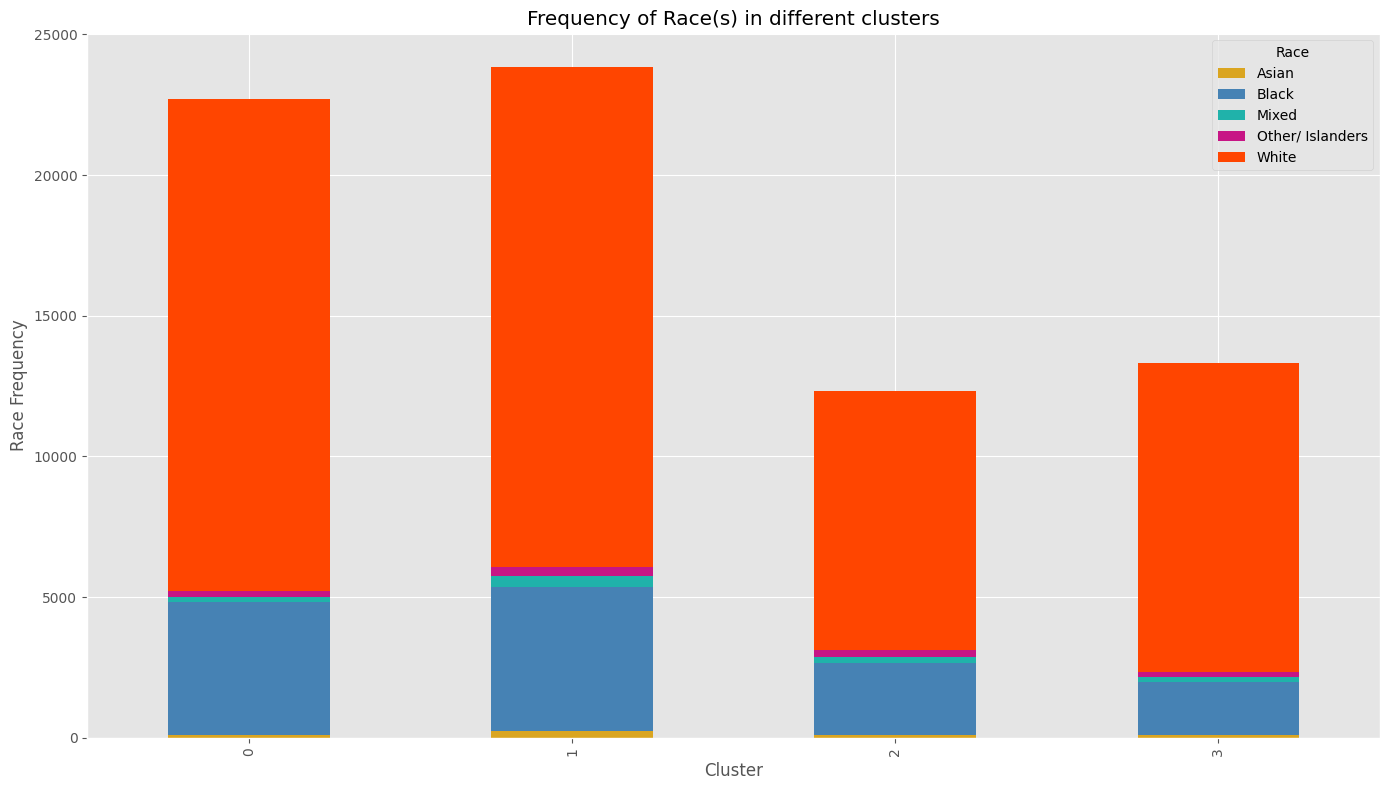

In [ ]:
frequency_race.plot(kind='bar', figsize=(14, 8), stacked=True, color=['#DAA520', '#4682B4', '#20B2AA', '#C71585', '#FF4500']) #width=0.8 
plt.title('Frequency of Race(s) in different clusters')
plt.ylabel('Race Frequency')
plt.xlabel('Cluster')
plt.legend(title='Race') 
plt.tight_layout() 

plt.show()

In [ ]:
frequency_death = fen_df_mode.pivot_table(index='Clusters', columns='Death', aggfunc='size')

frequency_death

Death,Accidental Drug Poisoning,Other
Clusters,,
0,21236,1465
1,22538,1310
2,11422,917
3,12652,683


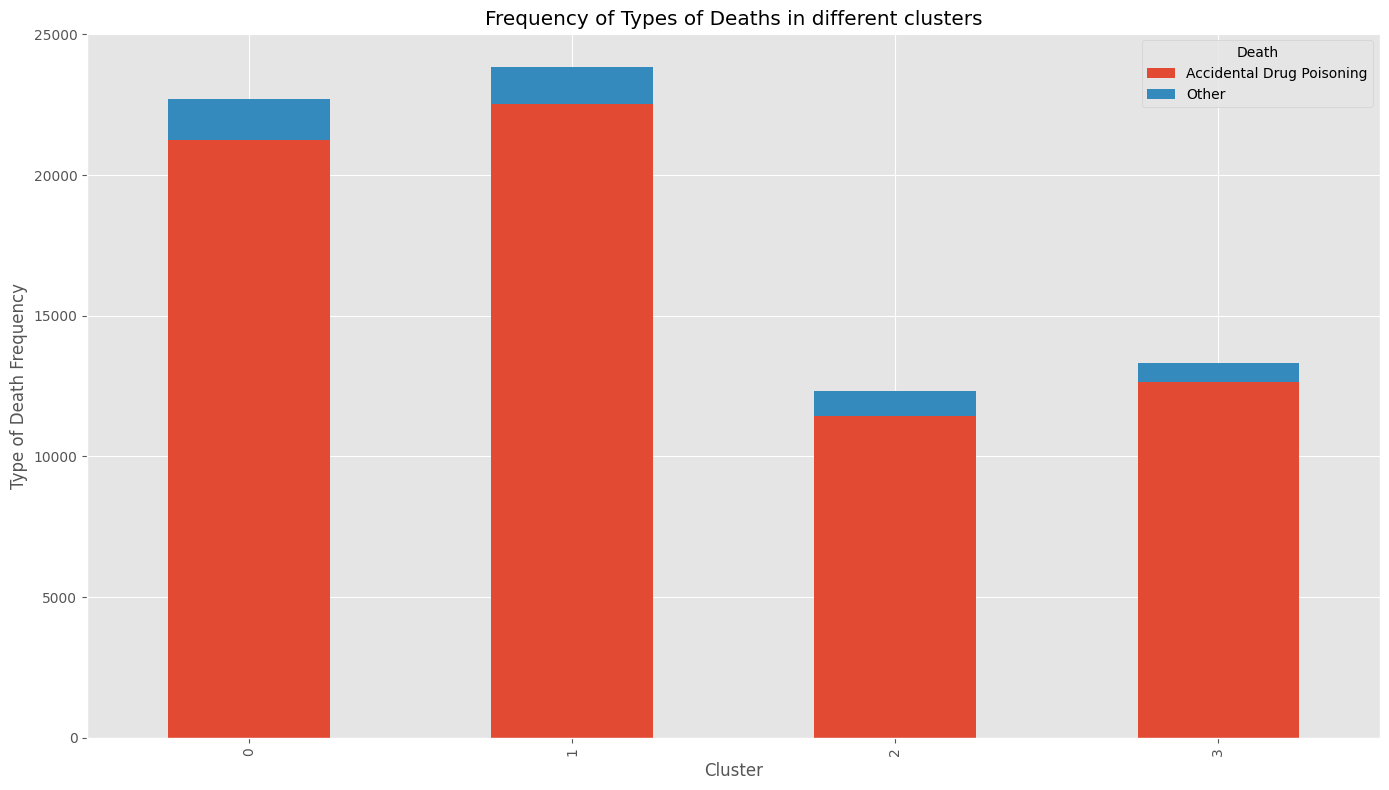

In [90]:
frequency_death.plot(kind='bar', figsize=(14, 8), stacked=True)
plt.title('Frequency of Types of Deaths in different clusters')
plt.ylabel('Type of Death Frequency')
plt.xlabel('Cluster')
plt.legend(title='Death') 
plt.tight_layout() #optimizes the spacing of everything

plt.show()

In [ ]:
heat_age = fen_df_mode.pivot_table(index='AgeCategory', columns='Clusters', aggfunc='size')
heat_age

Clusters,0,1,2,3
AgeCategory,,,,
18 and under,1,643,363,23
19 to 30,942,8529,4120,1848
31 to 40,1886,2031,5832,11397
41 to 50,4256,11068,0,0
51 to 65,14427,1046,1632,0
65 and up,1189,531,392,67


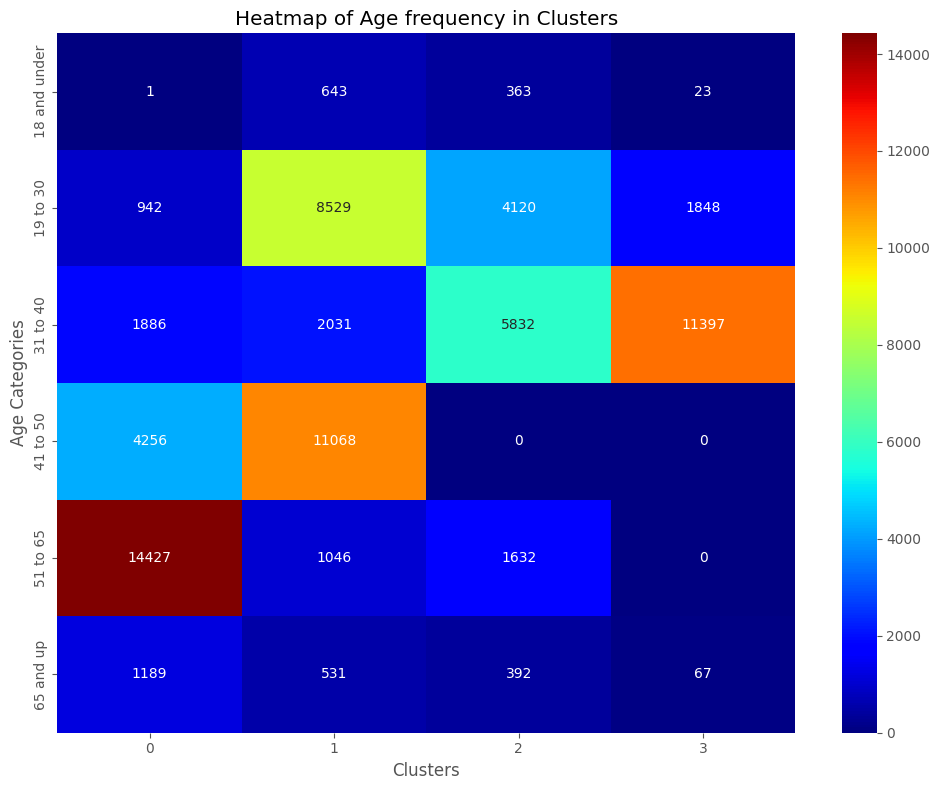

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(heat_age, annot=True, fmt="d", cmap="jet") 
plt.title('Heatmap of Age frequency in Clusters')
plt.ylabel('Age Categories')
plt.xlabel('Clusters')
plt.tight_layout()

plt.show()